<a href="https://colab.research.google.com/github/samueklcocla-ops/proyecto/blob/main/analisis_petroleo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Acciones: Occidental Petroleum y el Sector Petrolero

Este notebook analiza:
1. Las acciones de **Occidental Petroleum (OXY)** en la última década
2. Un panorama general de las principales **empresas petroleras**

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


---
## Parte 1: Occidental Petroleum (OXY) — Última Década

In [ ]:
# Descargamos datos de OXY desde Yahoo Finance
oxy_raw = yf.download("OXY", start="2015-01-01", progress=False)

# Nos quedamos con precio de cierre y volumen
oxy = oxy_raw[[('Close', 'OXY'), ('Volume', 'OXY')]].copy()
oxy.columns = ["precio_cierre", "volumen"]
oxy = oxy.dropna()

print(f"OXY cargado desde {oxy.index.min().date()} hasta {oxy.index.max().date()}")
print(f"Total: {len(oxy)} días de trading")
print(oxy.tail())

/tmp/ipykernel_8303/3337548794.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oxy_raw = yf.download("OXY", start="2015-01-01", progress=False)


OXY cargado desde 2015-01-02 hasta 2026-04-22
Total: 2842 días de trading
            precio_cierre   volumen
Date                               
2026-04-16      56.869999  10022400
2026-04-17      53.790001  24183800
2026-04-20      54.480000  11503600
2026-04-21      56.330002  15402500
2026-04-22      57.049999   8029282


### Gráfica 1: Precio histórico de OXY

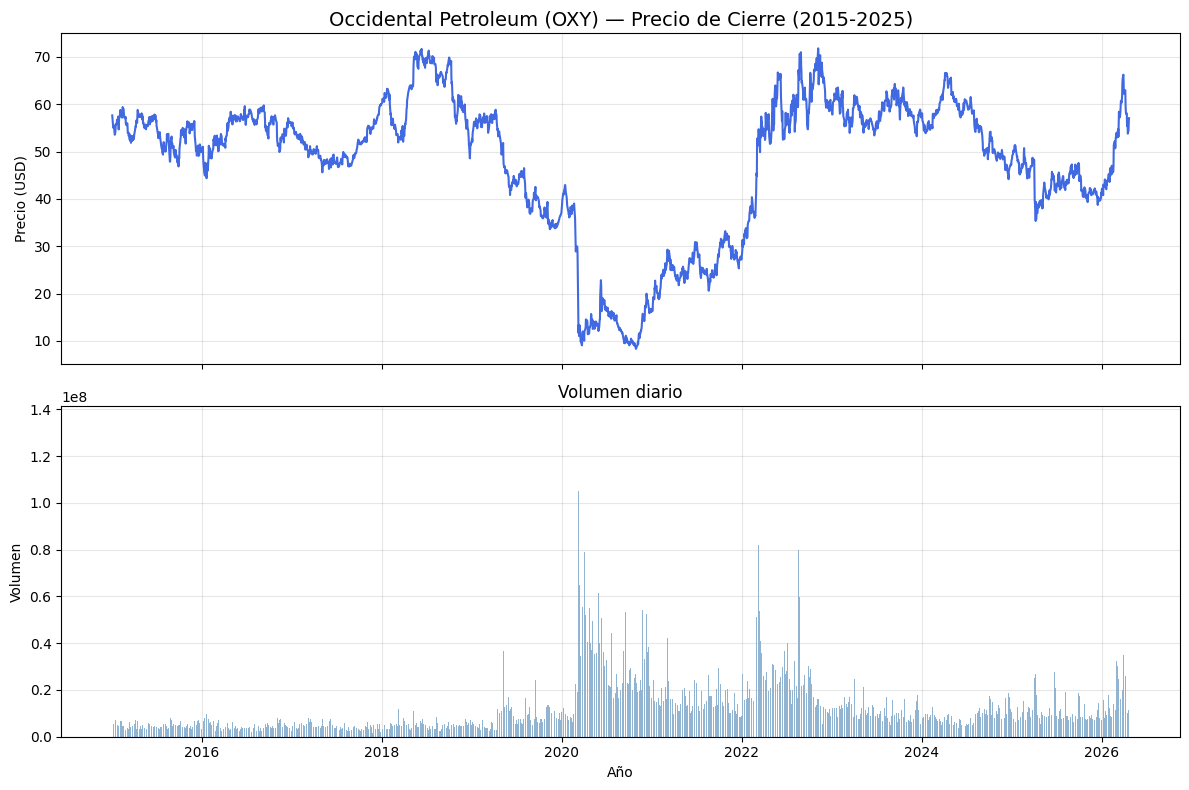

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Precio de cierre
ax1.plot(oxy.index, oxy["precio_cierre"], color="royalblue", linewidth=1.5)
ax1.set_title("Occidental Petroleum (OXY) — Precio de Cierre (2015-2025)", fontsize=14)
ax1.set_ylabel("Precio (USD)")
ax1.grid(True, alpha=0.3)

# Volumen
ax2.bar(oxy.index, oxy["volumen"], color="steelblue", alpha=0.6, width=1)
ax2.set_title("Volumen diario", fontsize=12)
ax2.set_ylabel("Volumen")
ax2.set_xlabel("Año")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Ingeniería de Características para OXY

In [ ]:
# Resampleamos a datos anuales (igual que en clase con AAPL)
oxy_anual = oxy.resample("YE").mean()
oxy_anual.index = oxy_anual.index.year

df = oxy_anual.copy()
df["año"] = oxy_anual.index
df["variacion_pct"] = df["precio_cierre"].pct_change() * 100
df["variacion_lag1"] = df["variacion_pct"].shift(1)
df["variacion_lag2"] = df["variacion_pct"].shift(2)
df["media_movil_3"] = df["variacion_pct"].rolling(window=3).mean()
df["variacion_volumen"] = df["volumen"].pct_change() * 100

df = df.dropna()

print("Características creadas:")
print(df.columns.tolist())
print(f"\nForma del dataframe: {df.shape}")
print(df)

Características creadas:
['precio_cierre', 'volumen', 'año', 'variacion_pct', 'variacion_lag1', 'variacion_lag2', 'media_movil_3', 'variacion_volumen']

Forma del dataframe: (9, 8)
      precio_cierre       volumen   año  variacion_pct  variacion_lag1  \
Date                                                                     
2018      62.518849  5.056785e+06  2018      22.821162       -6.884082   
2019      45.402328  8.649775e+06  2019     -27.378177       22.821162   
2020      17.598088  3.057218e+07  2020     -61.239679      -27.378177   
2021      25.818358  1.760088e+07  2021      46.711153      -61.239679   
2022      56.120574  2.550268e+07  2022     117.366941       46.711153   
2023      58.561177  1.092476e+07  2023       4.348856      117.366941   
2024      55.751379  9.636627e+06  2024      -4.798056        4.348856   
2025      43.571260  1.114400e+07  2025     -21.847208       -4.798056   
2026      51.750308  1.609210e+07  2026      18.771659      -21.847208   

    

### Modelo: Random Forest para predecir la variación anual de OXY

In [ ]:
features = ["año", "variacion_lag1", "variacion_lag2", "media_movil_3", "variacion_volumen"]

X = df[features]
y = df["variacion_pct"]

# División temporal (sin shuffle para respetar el orden cronológico)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Entrenamiento: {X_train.shape[0]} años ({X_train.index.min()} - {X_train.index.max()})")
print(f"Prueba: {X_test.shape[0]} años ({X_test.index.min()} - {X_test.index.max()})")

# Entrenamos el modelo
modelo = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMAE: {mae:.2f}%")
print(f"R2:  {r2:.4f}")

# Importancia de las variables
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportancia de variables:")
print(importancias)

Entrenamiento: 7 años (2018 - 2024)
Prueba: 2 años (2025 - 2026)

MAE: 20.63%
R2:  -0.0392

Importancia de variables:
variacion_lag2       0.476048
variacion_volumen    0.230648
variacion_lag1       0.128861
media_movil_3        0.118380
año                  0.046063
dtype: float64


---
## Parte 2: Panorama General — Sector Petrolero

In [ ]:
# Las principales empresas petroleras del mundo
empresas = {
    "OXY":  "Occidental Petroleum",
    "XOM":  "ExxonMobil",
    "CVX":  "Chevron",
    "BP":   "BP",
    "SHEL": "Shell",
    "COP":  "ConocoPhillips"
}

tickers = list(empresas.keys())

# Descargamos precios de cierre desde 2015
datos_raw = yf.download(tickers, start="2015-01-01", progress=False)
precios = datos_raw["Close"].copy()
precios.columns = [empresas[t] for t in precios.columns]
precios = precios.dropna()

print(f"Datos del sector cargados: {precios.shape[0]} días")
print(precios.tail())

/tmp/ipykernel_8303/4262697282.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos_raw = yf.download(tickers, start="2015-01-01", progress=False)


Datos del sector cargados: 2842 días
                   BP  ConocoPhillips     Chevron  Occidental Petroleum  \
Date                                                                      
2026-04-16  47.630001      121.570000  188.149994             56.869999   
2026-04-17  44.590000      116.040001  183.990005             53.790001   
2026-04-20  45.119999      116.449997  183.250000             54.480000   
2026-04-21  45.910000      120.260002  185.979996             56.330002   
2026-04-22  46.369999      122.599998  186.320007             57.049999   

                Shell  ExxonMobil  
Date                               
2026-04-16  91.500000  151.979996  
2026-04-17  87.809998  146.440002  
2026-04-20  88.000000  147.679993  
2026-04-21  88.660004  148.360001  
2026-04-22  89.489998  149.500000  


### Gráfica 2: Comparación de precios normalizados (base 100)

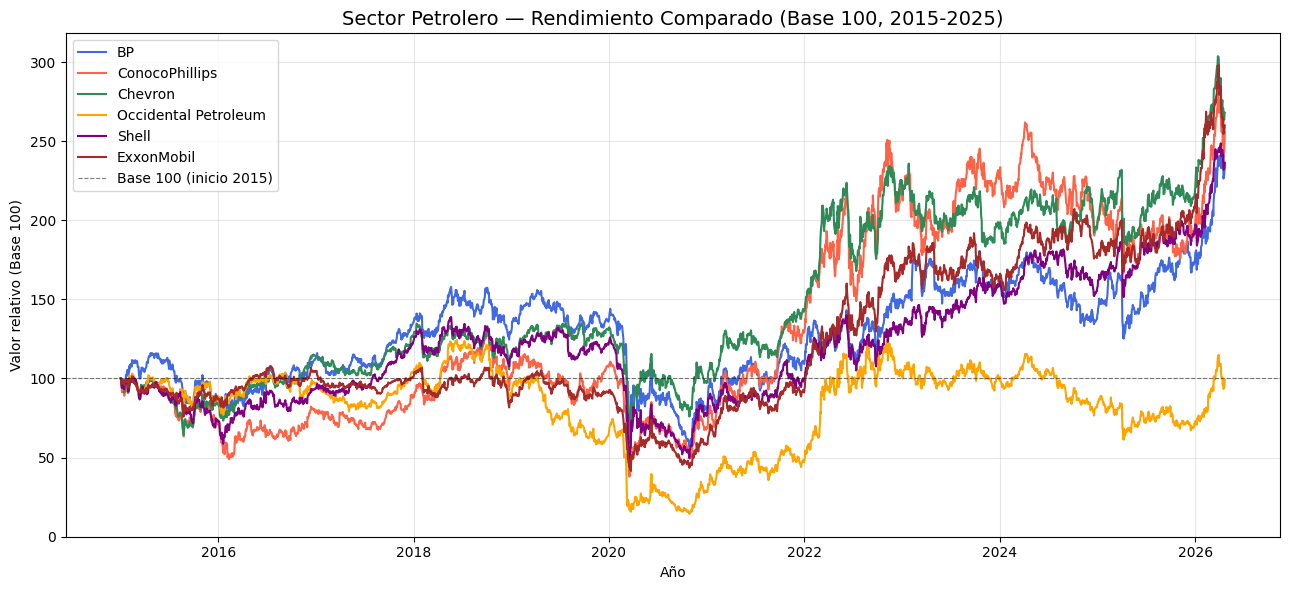

In [ ]:
# Normalizamos a base 100 para poder comparar todas las acciones
precios_norm = precios / precios.iloc[0] * 100

colores = ["royalblue", "tomato", "seagreen", "orange", "purple", "brown"]

plt.figure(figsize=(13, 6))

for col, color in zip(precios_norm.columns, colores):
    plt.plot(precios_norm.index, precios_norm[col], label=col, linewidth=1.5, color=color)

plt.axhline(y=100, color="black", linestyle="--", linewidth=0.8, alpha=0.5, label="Base 100 (inicio 2015)")
plt.title("Sector Petrolero — Rendimiento Comparado (Base 100, 2015-2025)", fontsize=14)
plt.ylabel("Valor relativo (Base 100)")
plt.xlabel("Año")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Estadísticas resumen del sector

In [ ]:
# Rendimiento anual de cada empresa
precios_anual = precios.resample("YE").last()
rendimiento_anual = precios_anual.pct_change() * 100
rendimiento_anual.index = rendimiento_anual.index.year
rendimiento_anual = rendimiento_anual.dropna()

print("Rendimiento anual (%) por empresa:")
print(rendimiento_anual.round(1).to_string())

print("\nPromedio de rendimiento anual por empresa:")
print(rendimiento_anual.mean().round(2).sort_values(ascending=False))

print("\nVolatilidad (desviación estándar del rendimiento anual):")
print(rendimiento_anual.std().round(2).sort_values(ascending=False))

### Gráfica 3: Rendimiento promedio anual vs Volatilidad (riesgo-retorno)

In [ ]:
promedio = rendimiento_anual.mean()
volatilidad = rendimiento_anual.std()

plt.figure(figsize=(9, 6))

for empresa, color in zip(promedio.index, colores):
    plt.scatter(volatilidad[empresa], promedio[empresa], color=color, s=120, zorder=5)
    plt.annotate(
        empresa,
        (volatilidad[empresa], promedio[empresa]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=10
    )

plt.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
plt.title("Riesgo vs Retorno — Sector Petrolero (2015-2025)", fontsize=13)
plt.xlabel("Volatilidad (desv. estándar del rendimiento anual, %)")
plt.ylabel("Rendimiento promedio anual (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Analisis de acciones: Petrobras
Este código analiza la situación de Petrobras desde dos enfoques:

* Mercado: comportamiento del precio de la acción y su evolución en el tiempo
* Financiero: ingresos, utilidades e indicadores como rentabilidad

Además, aplica un modelo de Random Forest para predecir el desempeño futuro y compara la empresa con otras petroleras, permitiendo tener una visión más completa del sector energético.

In [ ]:
# Importamos librerías necesarias

import yfinance as yf            # Para descargar datos financieros desde Yahoo Finance
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor  # Modelo de Machine Learning
from sklearn.model_selection import train_test_split # Para dividir datos en entrenamiento y prueba

In [ ]:
# Descargamos datos históricos de Petrobras (ticker: PBR)
pbr_raw = yf.download("PBR", start="2015-01-01", progress=False)

# Seleccionamos únicamente el precio de cierre y el volumen
pbr = pbr_raw[[('Close', 'PBR'), ('Volume', 'PBR')]].copy()

# Renombramos las columnas para que sean más fáciles de usar
pbr.columns = ["precio_cierre", "volumen"]

# Eliminamos valores faltantes para evitar errores en cálculos
pbr = pbr.dropna()

# Mostramos los últimos datos para verificar
print(pbr.tail())

/tmp/ipykernel_12077/2379502648.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pbr_raw = yf.download("PBR", start="2015-01-01", progress=False)


            precio_cierre   volumen
Date                               
2026-04-16      21.500000  31948400
2026-04-17      20.450001  42475700
2026-04-20      20.760000  18590700
2026-04-21      21.150000  13579600
2026-04-22      21.180000  16439279


In [ ]:
# Convertimos los datos diarios a datos anuales (promedio por año)
pbr_anual = pbr.resample("YE").mean()

# Cambiamos el índice para que muestre solo el año
pbr_anual.index = pbr_anual.index.year

# Copiamos los datos a un nuevo DataFrame para trabajar
df = pbr_anual.copy()

# Creamos nuevas variables (features) para el modelo

df["año"] = df.index  # Guardamos el año como variable numérica

# Calcula el porcentaje de cambio del precio respecto al año anterior
df["variacion_pct"] = df["precio_cierre"].pct_change() * 100

# Variables con retraso (lag), es decir, valores de años anteriores
df["variacion_lag1"] = df["variacion_pct"].shift(1)  # 1 año atrás
df["variacion_lag2"] = df["variacion_pct"].shift(2)  # 2 años atrás

# Promedio de los últimos 3 años (suaviza la tendencia)
df["media_movil_3"] = df["variacion_pct"].rolling(3).mean()

# Variación del volumen negociado
df["variacion_volumen"] = df["volumen"].pct_change() * 100

# Eliminamos filas con valores nulos generados por los cálculos
df = df.dropna()

# Mostramos el resultado final
print(df)

      precio_cierre       volumen   año  variacion_pct  variacion_lag1  \
Date                                                                     
2018       3.819783  2.412534e+07  2018      34.212057       27.325481   
2019       4.574419  1.628496e+07  2019      19.756007       34.212057   
2020       2.764215  2.619836e+07  2020     -39.572328       19.756007   
2021       3.284632  3.226512e+07  2021      18.826921      -39.572328   
2022       6.062711  3.374525e+07  2022      84.578094       18.826921   
2023       9.159696  2.053100e+07  2023      51.082522       84.578094   
2024      12.420368  1.738520e+07  2024      35.598039       51.082522   
2025      12.223840  2.107390e+07  2025      -1.582307       35.598039   
2026      16.956447  2.988477e+07  2026      38.716210       -1.582307   

      variacion_lag2  media_movil_3  variacion_volumen  
Date                                                    
2018       15.055237      25.530925          32.369356  
2019       27.

In [ ]:
# Definimos las variables que usará el modelo para predecir
features = ["año", "variacion_lag1", "variacion_lag2", "media_movil_3", "variacion_volumen"]

# X = variables de entrada (lo que el modelo usa)
X = df[features]

# y = variable objetivo (lo que queremos predecir)
y = df["variacion_pct"]

# Dividimos los datos en entrenamiento (80%) y prueba (20%)
# shuffle=False es clave para respetar el orden del tiempo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Creamos el modelo Random Forest (muchos árboles de decisión)
modelo = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Evaluamos qué tan bien predice
print("Score:", modelo.score(X_test, y_test))

Score: -0.10336960747929758


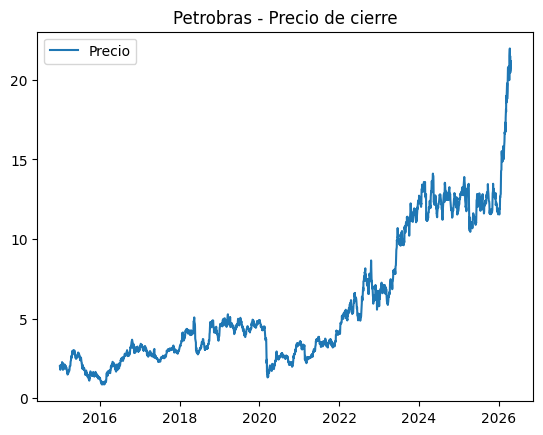

In [ ]:
# Creamos una figura para graficar
plt.figure()

# Graficamos el precio de cierre a lo largo del tiempo
plt.plot(pbr.index, pbr["precio_cierre"], label="Precio")

# Título del gráfico
plt.title("Petrobras - Precio de cierre")

# Mostramos leyenda
plt.legend()

# Mostramos la gráfica
plt.show()

/tmp/ipykernel_12077/1053144941.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(list(empresas.keys()), start="2015-01-01")["Close"]
[*********************100%***********************]  5 of 5 completed


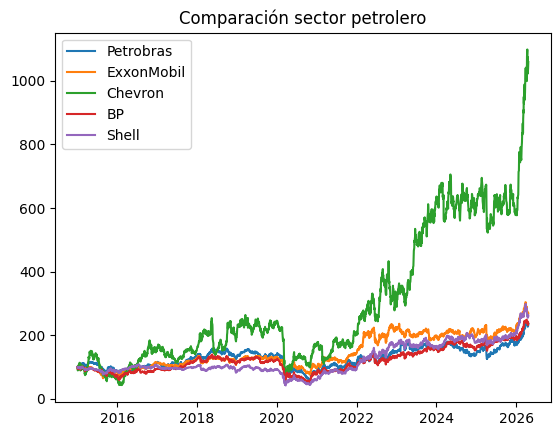

In [ ]:
# Definimos empresas del sector
empresas = {
    "PBR": "Petrobras",
    "XOM": "ExxonMobil",
    "CVX": "Chevron",
    "BP": "BP",
    "SHEL": "Shell"
}

# Descargamos precios de todas las empresas
datos = yf.download(list(empresas.keys()), start="2015-01-01")["Close"]

# Renombramos columnas con nombres reales
datos.columns = empresas.values()

# Normalizamos los precios (todos empiezan en 100)
datos_norm = datos / datos.iloc[0] * 100

# Creamos gráfica comparativa
plt.figure()

# Graficamos cada empresa
for col in datos_norm.columns:
    plt.plot(datos_norm.index, datos_norm[col], label=col)

# Mostramos leyenda
plt.legend()

# Título del gráfico
plt.title("Comparación sector petrolero")

# Mostramos gráfica
plt.show()

ECOPETROL

Librerías cargadas correctamente


/tmp/ipykernel_9755/1481111048.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eco_raw = yf.download("EC", start="2015-01-01", progress=False)


Ecopetrol cargado desde 2015-01-02 hasta 2026-04-23
Total: 2843 días de trading
            precio_cierre  volumen
Date                              
2026-04-17          13.55  5567400
2026-04-20          13.66  1975800
2026-04-21          14.15  2924100
2026-04-22          14.32  2297400
2026-04-23          14.43  2094115


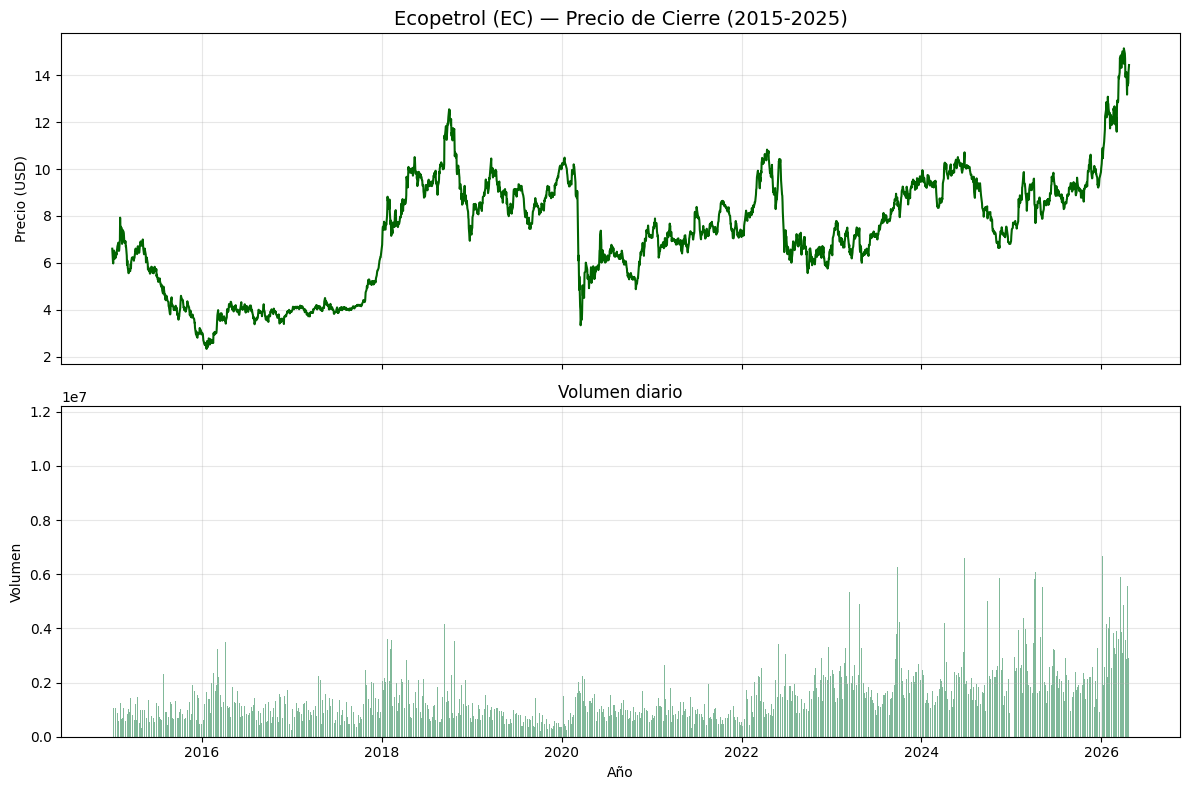

Características creadas:
['precio_cierre', 'volumen', 'año', 'variacion_pct', 'variacion_lag1', 'variacion_lag2', 'media_movil_3', 'variacion_volumen']

Forma del dataframe: (9, 8)
      precio_cierre       volumen   año  variacion_pct  variacion_lag1  \
Date                                                                     
2018       9.309313  1.382071e+06  2018     116.319040       17.024026   
2019       8.820539  6.869464e+05  2019      -5.250371      116.319040   
2020       6.615422  1.092175e+06  2020     -24.999797       -5.250371   
2021       7.362201  9.502151e+05  2021      11.288443      -24.999797   
2022       7.719136  1.602605e+06  2022       4.848212       11.288443   
2023       7.734243  2.073073e+06  2023       0.195718        4.848212   
2024       8.900165  2.112864e+06  2024      15.074800        0.195718   
2025       8.961396  2.340201e+06  2025       0.687970       15.074800   
2026      12.969481  3.418013e+06  2026      44.726124        0.687970   

    

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("Librerías cargadas correctamente")

# Descargamos datos de Ecopetrol (ticker: EC)
eco_raw = yf.download("EC", start="2015-01-01", progress=False)

# Nos quedamos con precio de cierre y volumen
eco = eco_raw[[('Close', 'EC'), ('Volume', 'EC')]].copy()
eco.columns = ["precio_cierre", "volumen"]
eco = eco.dropna()

print(f"Ecopetrol cargado desde {eco.index.min().date()} hasta {eco.index.max().date()}")
print(f"Total: {len(eco)} días de trading")
print(eco.tail())

# Gráficas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Precio de cierre
ax1.plot(eco.index, eco["precio_cierre"], color="darkgreen", linewidth=1.5)
ax1.set_title("Ecopetrol (EC) — Precio de Cierre (2015-2025)", fontsize=14)
ax1.set_ylabel("Precio (USD)")
ax1.grid(True, alpha=0.3)

# Volumen
ax2.bar(eco.index, eco["volumen"], color="seagreen", alpha=0.6, width=1)
ax2.set_title("Volumen diario", fontsize=12)
ax2.set_ylabel("Volumen")
ax2.set_xlabel("Año")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resampleamos a datos anuales
eco_anual = eco.resample("YE").mean()
eco_anual.index = eco_anual.index.year

df = eco_anual.copy()
df["año"] = eco_anual.index
df["variacion_pct"] = df["precio_cierre"].pct_change() * 100
df["variacion_lag1"] = df["variacion_pct"].shift(1)
df["variacion_lag2"] = df["variacion_pct"].shift(2)
df["media_movil_3"] = df["variacion_pct"].rolling(window=3).mean()
df["variacion_volumen"] = df["volumen"].pct_change() * 100

df = df.dropna()

print("Características creadas:")
print(df.columns.tolist())
print(f"\nForma del dataframe: {df.shape}")
print(df)

# Variables
features = ["año", "variacion_lag1", "variacion_lag2", "media_movil_3", "variacion_volumen"]

X = df[features]
y = df["variacion_pct"]

# División temporal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Entrenamiento: {X_train.shape[0]} años ({X_train.index.min()} - {X_train.index.max()})")
print(f"Prueba: {X_test.shape[0]} años ({X_test.index.min()} - {X_test.index.max()})")

# Modelo
modelo = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMAE: {mae:.2f}%")
print(f"R2:  {r2:.4f}")

# Importancia de variables
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportancia de variables:")
print(importancias)